In [155]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.datasets import load_diabetes, load_iris, load_wine
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)
from typing import List, Optional, Tuple, Union
from xgboost import XGBClassifier, XGBRegressor

In [156]:
PATH_DIRECTORIO_DATOS = "../data"

In [157]:
PATH_DATASET_HOTELES_PREPROCESSED = f"{PATH_DIRECTORIO_DATOS}/dataset_preprocessed.parquet"


In [158]:
df_hoteles_preprocessed = pd.read_parquet(PATH_DATASET_HOTELES_PREPROCESSED)
df_hoteles_preprocessed_without_deposit_type = df_hoteles_preprocessed.drop(columns=[col for col in df_hoteles_preprocessed.columns if col.startswith("deposit_type_")])


In [159]:
df_hoteles_preprocessed

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,arrival_month_sin,arrival_month_cos,adr_per_person,adr_per_night,meal_FB,meal_HB,meal_SC,meal_Undefined,deposit_type_Non Refund,deposit_type_Refundable
0,0,7,2015,27,1,0,1,1,0,0,...,-0.500000,-0.866025,75.000000,75.000000,False,False,False,False,False,False
1,0,13,2015,27,1,0,1,1,0,0,...,-0.500000,-0.866025,75.000000,75.000000,False,False,False,False,False,False
2,0,14,2015,27,1,0,2,2,0,0,...,-0.500000,-0.866025,49.000000,49.000000,False,False,False,False,False,False
3,0,14,2015,27,1,0,2,2,0,0,...,-0.500000,-0.866025,49.000000,49.000000,False,False,False,False,False,False
4,0,0,2015,27,1,0,2,2,0,0,...,-0.500000,-0.866025,53.500000,53.500000,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118558,0,23,2017,35,30,2,5,2,0,0,...,-0.866025,-0.500000,48.070000,13.734286,False,False,False,False,False,False
118559,0,102,2017,35,31,2,5,3,0,0,...,-0.866025,-0.500000,75.143333,32.204286,False,False,False,False,False,False
118560,0,34,2017,35,31,2,5,2,0,0,...,-0.866025,-0.500000,78.855000,22.530000,False,False,False,False,False,False
118561,0,109,2017,35,31,2,5,2,0,0,...,-0.866025,-0.500000,52.200000,14.914286,False,False,False,False,False,False


In [160]:
df_hoteles_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118563 entries, 0 to 118562
Data columns (total 50 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   is_canceled                     118563 non-null  int64  
 1   lead_time                       118563 non-null  int64  
 2   arrival_date_year               118563 non-null  int64  
 3   arrival_date_week_number        118563 non-null  int64  
 4   arrival_date_day_of_month       118563 non-null  int64  
 5   stays_in_weekend_nights         118563 non-null  int64  
 6   stays_in_week_nights            118563 non-null  int64  
 7   adults                          118563 non-null  int64  
 8   children                        118563 non-null  int64  
 9   babies                          118563 non-null  int64  
 10  is_repeated_guest               118563 non-null  int64  
 11  previous_cancellations          118563 non-null  int64  
 12  previous_booking

In [161]:
df_hoteles_preprocessed_backup = df_hoteles_preprocessed.copy()
df_hoteles_preprocessed_without_deposit_type_backup = df_hoteles_preprocessed_without_deposit_type.copy()

In [162]:
target_variable = "is_canceled"
list_independent_variables = df_hoteles_preprocessed.columns.drop(target_variable).tolist()

X = df_hoteles_preprocessed[list_independent_variables]
y = df_hoteles_preprocessed[target_variable]

In [163]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [164]:
cols_to_scale = [
    "lead_time",
    "arrival_date_year", "arrival_date_week_number", "arrival_date_day_of_month",
    "stays_in_weekend_nights", "stays_in_week_nights",
    "adults", "children", "babies",
    "previous_cancellations", "previous_bookings_not_canceled",
    "booking_changes", "days_in_waiting_list",
    "adr", "adr_per_person", "adr_per_night",
    "required_car_parking_spaces", "total_of_special_requests",
    "total_guests", "total_nights",
]

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

In [165]:
dict_parametros = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}


rl_model = LogisticRegression(max_iter=500, random_state=42)
rl_model_grid_search = GridSearchCV(estimator=rl_model, param_grid=dict_parametros, cv=5, scoring='accuracy')
rl_model_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=500, random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear']},
             scoring='accuracy')

In [166]:
print(f"Mejores hiperparámetros encontrados: {rl_model_grid_search.best_params_}")
print(f"Mejor score obtenido: {rl_model_grid_search.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'C': 10, 'solver': 'liblinear'}
Mejor score obtenido: 80.94%


In [167]:
rl_model_grid_search.best_estimator_

LogisticRegression(C=10, max_iter=500, random_state=42, solver='liblinear')

In [168]:
rl_model = rl_model_grid_search.best_estimator_
y_pred = rl_model.predict(X_test)

In [169]:
coefs = pd.Series(rl_model.coef_[0], index=X_train.columns)
coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(20)

required_car_parking_spaces      -8.000635
deposit_type_Non Refund           5.428872
previous_cancellations            2.423430
market_segment_Offline TA/TO     -1.485315
market_segment_Direct            -1.326593
has_company                      -1.009572
meal_Undefined                   -0.869495
market_segment_Groups            -0.826775
customer_type_Transient           0.761264
previous_bookings_not_canceled   -0.746183
market_segment_Complementary     -0.586898
is_repeated_guest                -0.583266
total_of_special_requests        -0.582239
meal_FB                           0.488883
reserved_room_type_F             -0.435777
lead_time                         0.430872
reserved_room_type_L              0.395258
market_segment_Corporate         -0.335719
customer_type_Transient-Party     0.310048
reserved_room_type_G             -0.274834
dtype: float64

In [170]:
acc = accuracy_score(y_test, y_pred)
print(acc)

0.80964028170202


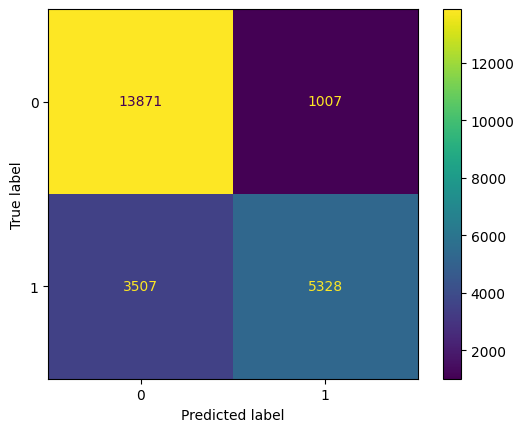

In [171]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rl_model.classes_)
disp.plot()

In [172]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7982    0.9323    0.8601     14878
           1     0.8410    0.6031    0.7024      8835

    accuracy                         0.8096     23713
   macro avg     0.8196    0.7677    0.7812     23713
weighted avg     0.8142    0.8096    0.8013     23713



In [173]:
##hacemos lo mismo pero con el dataset sin las columnas de deposit_type
X = df_hoteles_preprocessed_without_deposit_type.drop(columns=[target_variable])
y = df_hoteles_preprocessed_without_deposit_type[target_variable]

In [174]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [175]:
cols_to_scale = [
    "lead_time",
    "arrival_date_year", "arrival_date_week_number", "arrival_date_day_of_month",
    "stays_in_weekend_nights", "stays_in_week_nights",
    "adults", "children", "babies",
    "previous_cancellations", "previous_bookings_not_canceled",
    "booking_changes", "days_in_waiting_list",
    "adr", "adr_per_person", "adr_per_night",
    "required_car_parking_spaces", "total_of_special_requests",
    "total_guests", "total_nights",
]

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

In [176]:
dict_parametros = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}


rl_model = LogisticRegression(max_iter=500, random_state=42)
rl_model_grid_search = GridSearchCV(estimator=rl_model, param_grid=dict_parametros, cv=5, scoring='accuracy')
rl_model_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=500, random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear']},
             scoring='accuracy')

In [177]:
print(f"Mejores hiperparámetros encontrados: {rl_model_grid_search.best_params_}")
print(f"Mejor score obtenido: {rl_model_grid_search.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'C': 10, 'solver': 'liblinear'}
Mejor score obtenido: 78.75%


In [178]:
rl_model = rl_model_grid_search.best_estimator_
y_pred = rl_model.predict(X_test)

In [179]:
coefs = pd.Series(rl_model.coef_[0], index=X_train.columns)
coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(20)

required_car_parking_spaces      -8.465720
previous_cancellations            2.627757
market_segment_Direct            -1.394366
customer_type_Transient           1.293536
has_company                      -1.160573
meal_Undefined                   -1.027400
is_repeated_guest                -0.935359
previous_bookings_not_canceled   -0.836717
market_segment_Groups             0.688943
total_of_special_requests        -0.648061
market_segment_Offline TA/TO     -0.616805
lead_time                         0.614369
reserved_room_type_F             -0.592673
customer_type_Transient-Party    -0.404357
market_segment_Complementary     -0.402824
meal_FB                           0.395299
reserved_room_type_B              0.365378
adr                               0.330617
reserved_room_type_G             -0.321603
booking_changes                  -0.307220
dtype: float64

In [180]:
acc = accuracy_score(y_test, y_pred)
print(acc)

0.787837894825623


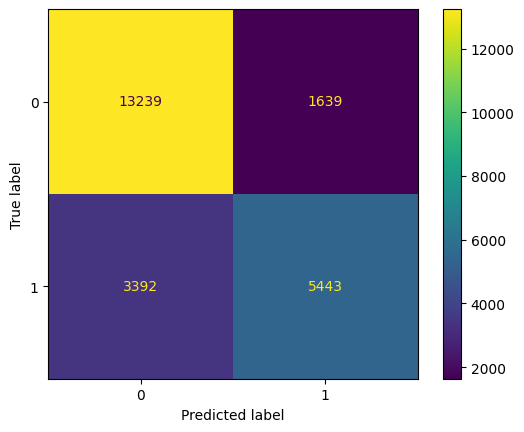

In [181]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rl_model.classes_)
disp.plot()

In [182]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7960    0.8898    0.8403     14878
           1     0.7686    0.6161    0.6839      8835

    accuracy                         0.7878     23713
   macro avg     0.7823    0.7530    0.7621     23713
weighted avg     0.7858    0.7878    0.7821     23713



In [183]:
df_conservative = df_hoteles_preprocessed_without_deposit_type.drop(
    columns=["required_car_parking_spaces"]
)


In [184]:
X = df_conservative.drop(columns=[target_variable])
y = df_conservative[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)   

In [185]:
cols_to_scale = [
    "lead_time",
    "arrival_date_year", "arrival_date_week_number", "arrival_date_day_of_month",
    "stays_in_weekend_nights", "stays_in_week_nights",
    "adults", "children", "babies",
    "previous_cancellations", "previous_bookings_not_canceled",
    "booking_changes", "days_in_waiting_list",
    "adr", "adr_per_person", "adr_per_night", "total_of_special_requests",
    "total_guests", "total_nights",
]

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

In [186]:
dict_parametros = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}


rl_model = LogisticRegression(max_iter=500, random_state=42)
rl_model_grid_search = GridSearchCV(estimator=rl_model, param_grid=dict_parametros, cv=5, scoring='accuracy')
rl_model_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=500, random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear']},
             scoring='accuracy')

In [187]:
print(f"Mejores hiperparámetros encontrados: {rl_model_grid_search.best_params_}")
print(f"Mejor score obtenido: {rl_model_grid_search.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'C': 0.1, 'solver': 'liblinear'}
Mejor score obtenido: 78.33%


In [188]:
rl_model = rl_model_grid_search.best_estimator_
y_pred = rl_model.predict(X_test)

In [189]:
coefs = pd.Series(rl_model.coef_[0], index=X_train.columns)
coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(20)

previous_cancellations            2.475264
market_segment_Direct            -1.305172
customer_type_Transient           1.177335
has_company                      -1.114668
market_segment_Groups             0.850424
is_repeated_guest                -0.829524
previous_bookings_not_canceled   -0.814118
meal_Undefined                   -0.804481
total_of_special_requests        -0.651495
lead_time                         0.619894
reserved_room_type_F             -0.554881
customer_type_Transient-Party    -0.483487
market_segment_Offline TA/TO     -0.459937
meal_FB                           0.421500
reserved_room_type_G             -0.397989
market_segment_Corporate          0.382928
reserved_room_type_H             -0.358446
booking_changes                  -0.323709
reserved_room_type_B              0.322512
reserved_room_type_D             -0.271627
dtype: float64

In [190]:
acc = accuracy_score(y_test, y_pred)
print(acc)

0.7839581664066124


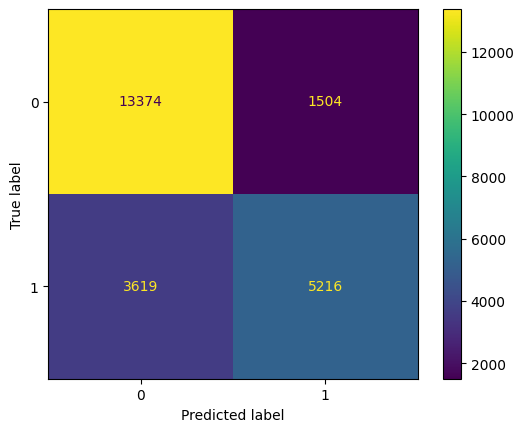

In [191]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rl_model.classes_)
disp.plot()

In [192]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7870    0.8989    0.8393     14878
           1     0.7762    0.5904    0.6707      8835

    accuracy                         0.7840     23713
   macro avg     0.7816    0.7446    0.7550     23713
weighted avg     0.7830    0.7840    0.7764     23713

